In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay)



In [10]:
# 1. Carga y Preparación (Foco Transversal)
# Cargamos el set que analiza a los sujetos en un único momento del tiempo [9]
df = pd.read_csv('oasis_cross-sectional.csv')

# Selección de variables predictoras clínicas y demográficas [10]
features = ['Sex', 'Age', 'Educ', 'SES', 'MMSE', 'eTIV', 'nWBV', 'ASF']
X = df[features].copy()

# Codificación de variable binaria (Sexo) [11]
X['Sex'] = X['Sex'].map({'M': 0, 'F': 1})

# --- LINEAMIENTO: Binarización del Target (CDR) ---
# CDR 0 -> 0 ("non demented"), CDR >= 0.5 -> 1 ("demented") [Instrucción]
y = df['CDR'].apply(lambda x: 1 if x >= 0.5 else 0)


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Iniciando 10 validaciones independientes para Naive Bayes...


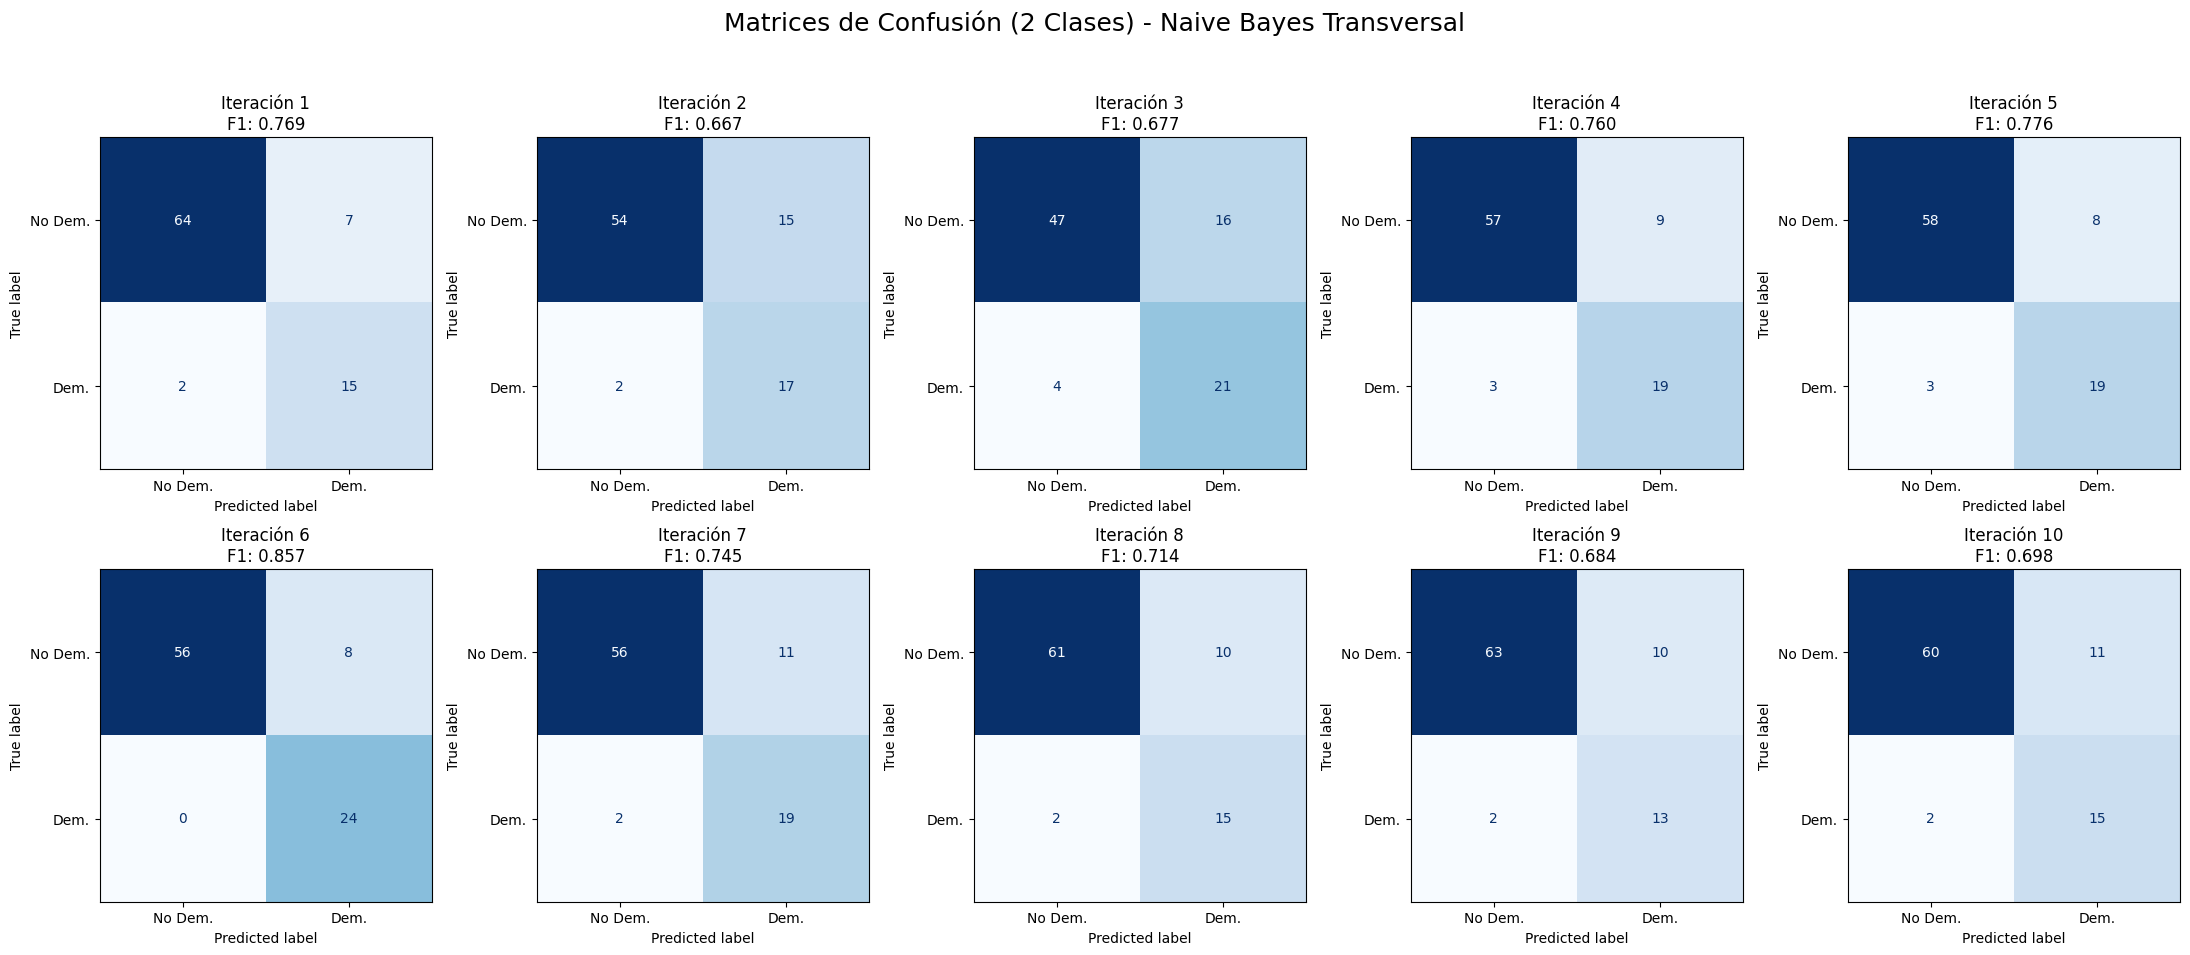


--- DESEMPEÑO FINAL NAIVE BAYES (10 ITERACIONES) ---
Métrica              | Promedio ± DE       
--------------------------------------------------
ACC                  | 0.8557 ± 0.0380
PREC                 | 0.6288 ± 0.0681
REC                  | 0.8880 ± 0.0411
F1                   | 0.7347 ± 0.0555
AUC                  | 0.9537 ± 0.0132


In [11]:
# El dataset transversal tiene nulos en SES y Educ [12, 13]. 
# Imputamos por mediana para no perder muestras valiosas [14].
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)

# 3. Configuración del Diseño Experimental (10 Validaciones 80/20)
# Creamos contenedores para las métricas de las 10 repeticiones [7]
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Iniciando 10 validaciones independientes para Naive Bayes...")

for i in range(10):
    # Partición aleatoria única por iteración (80% entrenamiento / 20% prueba) [7]
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 4. Entrenamiento del Modelo Gaussian Naive Bayes
    # Este modelo es ideal para variables biomédicas continuas [4, 5]
    nb = GaussianNB()
    nb.fit(X_train, y_train)
    
    # Predicciones
    y_pred = nb.predict(X_test)
    y_proba = nb.predict_proba(X_test)[:, 1] # Probabilidades para AUC [15]
    
    # 5. Cálculo y Registro de Métricas [8]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 6. Visualización: Matriz de Confusión por iteración [16]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dem.', 'Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión (2 Clases) - Naive Bayes Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Reporte Estadístico Final (Media ± DE) [8, 17]
print("\n" + "="*50)
print(f"--- DESEMPEÑO FINAL NAIVE BAYES (10 ITERACIONES) ---")
print(f"{'Métrica':<20} | {'Promedio ± DE':<20}")
print("-" * 50)
for m in results:
    print(f"{m.upper():<20} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*50)

/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


Iniciando 10 validaciones independientes para Naive Bayes...


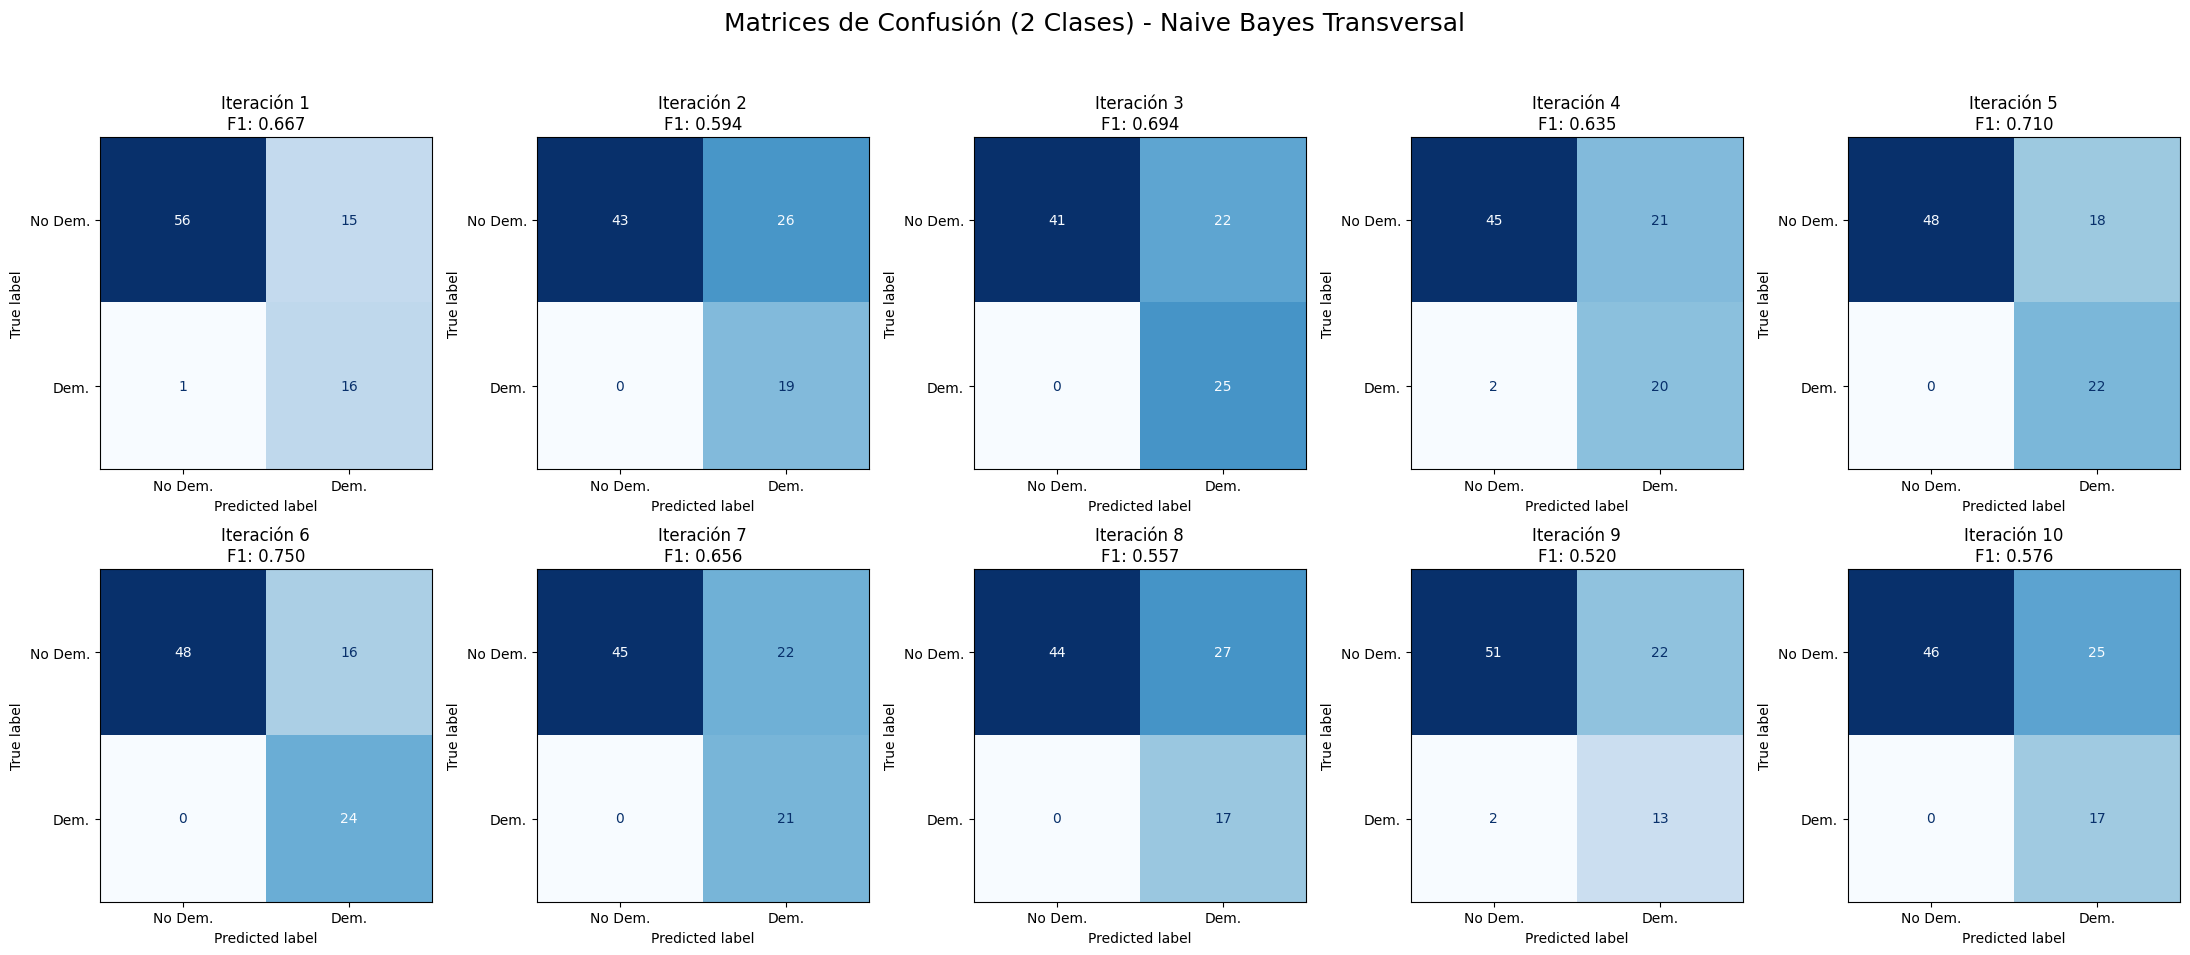


--- DESEMPEÑO FINAL NAIVE BAYES (10 ITERACIONES) ---
Métrica              | Promedio ± DE       
--------------------------------------------------
ACC                  | 0.7511 ± 0.0430
PREC                 | 0.4759 ± 0.0727
REC                  | 0.9717 ± 0.0464
F1                   | 0.6359 ± 0.0694
AUC                  | 0.8441 ± 0.0293


In [12]:
# El dataset transversal tiene nulos en SES y Educ [12, 13]. 
# Imputamos por mediana para no perder muestras valiosas [14].
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)

# 3. Configuración del Diseño Experimental (10 Validaciones 80/20)
# Creamos contenedores para las métricas de las 10 repeticiones [7]
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Iniciando 10 validaciones independientes para Naive Bayes...")

for i in range(10):
    # Partición aleatoria única por iteración (80% entrenamiento / 20% prueba) [7]
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 4. Entrenamiento del Modelo Gaussian Naive Bayes
    # Este modelo es ideal para variables biomédicas continuas [4, 5]
    nb = MultinomialNB()
    nb.fit(X_train, y_train)
    
    # Predicciones
    y_pred = nb.predict(X_test)
    y_proba = nb.predict_proba(X_test)[:, 1] # Probabilidades para AUC [15]
    
    # 5. Cálculo y Registro de Métricas [8]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 6. Visualización: Matriz de Confusión por iteración [16]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dem.', 'Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión (2 Clases) - Naive Bayes Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Reporte Estadístico Final (Media ± DE) [8, 17]
print("\n" + "="*50)
print(f"--- DESEMPEÑO FINAL NAIVE BAYES (10 ITERACIONES) ---")
print(f"{'Métrica':<20} | {'Promedio ± DE':<20}")
print("-" * 50)
for m in results:
    print(f"{m.upper():<20} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*50)

Iniciando 10 validaciones independientes para Naive Bayes...


/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/impute/_base.py:641: UserWarning: Skipping features without any observed values: ['Sex']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/felipemendez/Uni/mineria_de_datos/Proyecto2/Proyecto-2-Mineria-de-datos/.venv/lib64/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this b

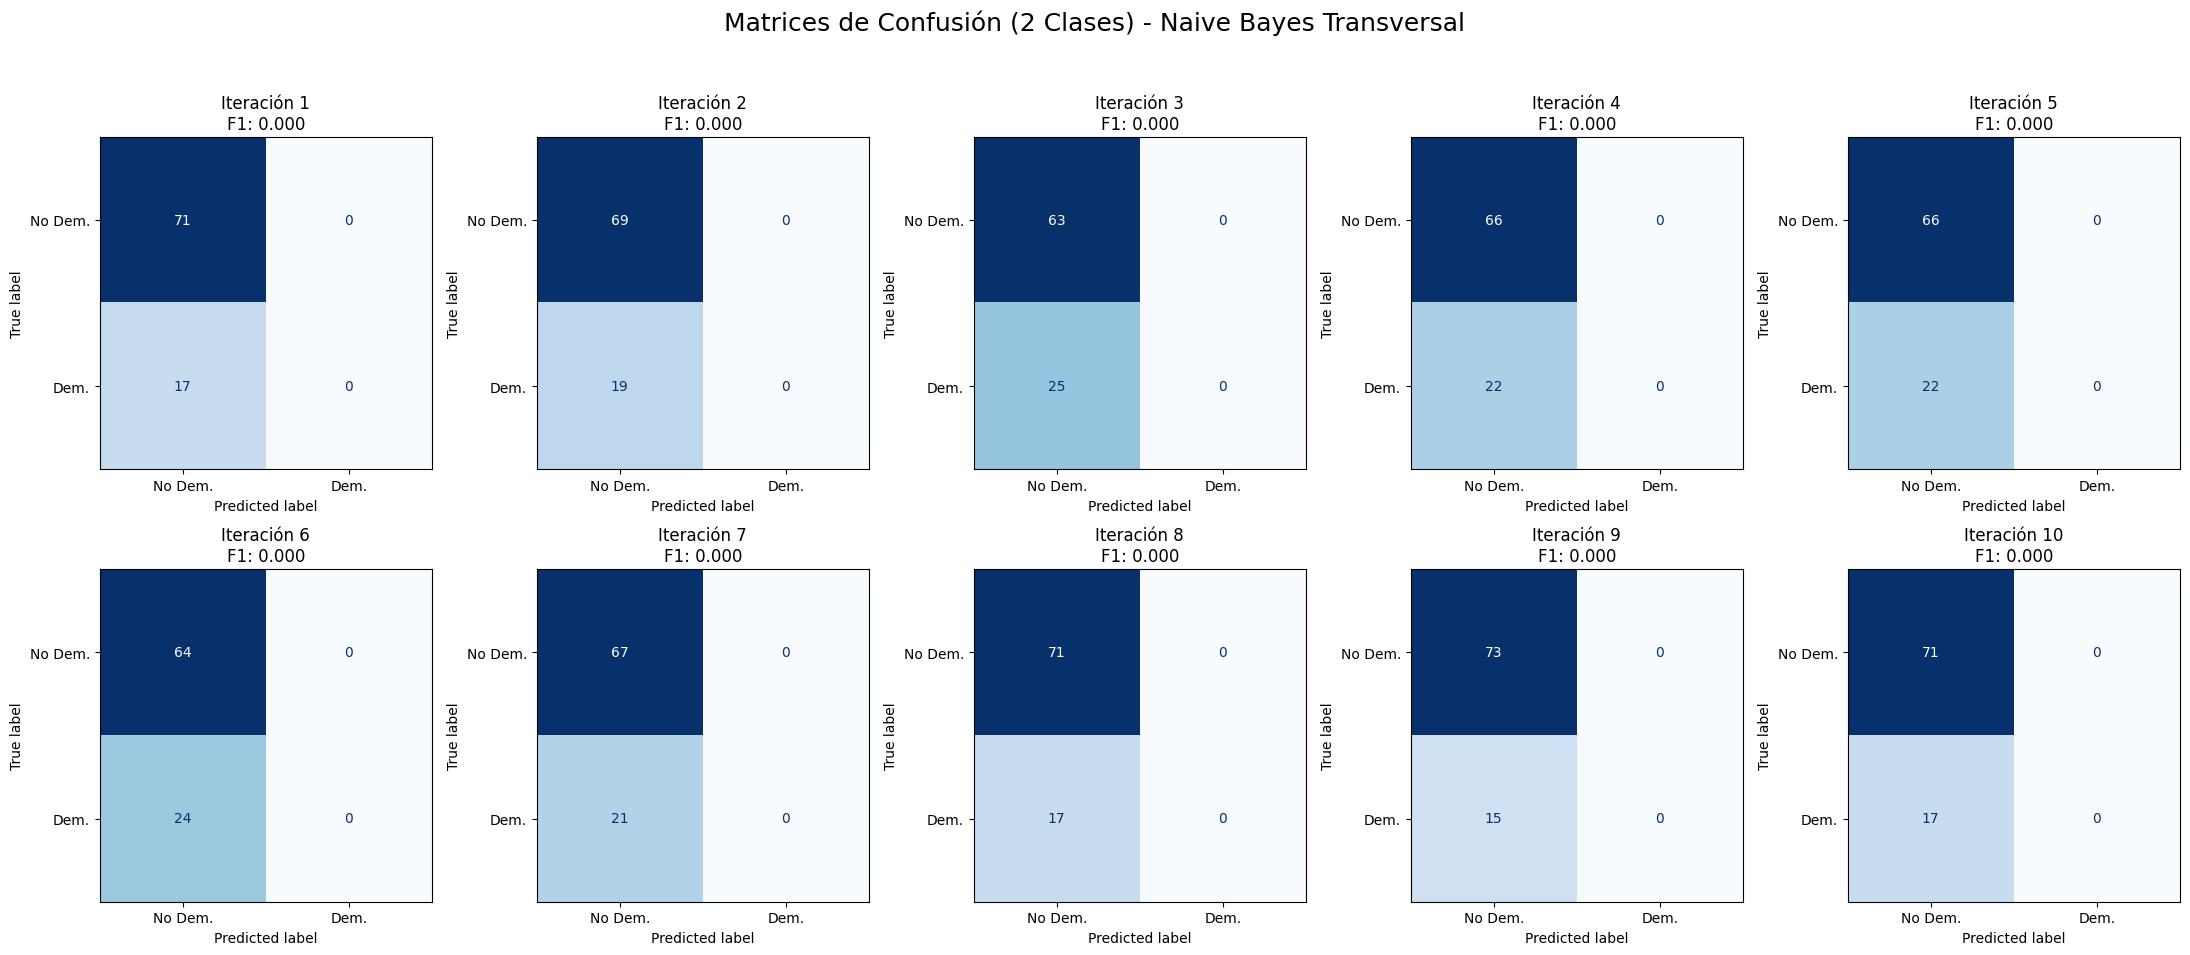


--- DESEMPEÑO FINAL NAIVE BAYES (10 ITERACIONES) ---
Métrica              | Promedio ± DE       
--------------------------------------------------
ACC                  | 0.7739 ± 0.0365
PREC                 | 0.0000 ± 0.0000
REC                  | 0.0000 ± 0.0000
F1                   | 0.0000 ± 0.0000
AUC                  | 0.5000 ± 0.0000


In [13]:
# El dataset transversal tiene nulos en SES y Educ [12, 13]. 
# Imputamos por mediana para no perder muestras valiosas [14].
imputer = SimpleImputer(strategy='median')
X_prep = imputer.fit_transform(X)

# 3. Configuración del Diseño Experimental (10 Validaciones 80/20)
# Creamos contenedores para las métricas de las 10 repeticiones [7]
results = {'acc': [], 'prec': [], 'rec': [], 'f1': [], 'auc': []}
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
axes = axes.flatten()

print("Iniciando 10 validaciones independientes para Naive Bayes...")

for i in range(10):
    # Partición aleatoria única por iteración (80% entrenamiento / 20% prueba) [7]
    X_train, X_test, y_train, y_test = train_test_split(
        X_prep, y, test_size=0.2, random_state=i
    )
    
    # 4. Entrenamiento del Modelo Gaussian Naive Bayes
    # Este modelo es ideal para variables biomédicas continuas [4, 5]
    nb = BernoulliNB()
    nb.fit(X_train, y_train)
    
    # Predicciones
    y_pred = nb.predict(X_test)
    y_proba = nb.predict_proba(X_test)[:, 1] # Probabilidades para AUC [15]
    
    # 5. Cálculo y Registro de Métricas [8]
    results['acc'].append(accuracy_score(y_test, y_pred))
    results['prec'].append(precision_score(y_test, y_pred))
    results['rec'].append(recall_score(y_test, y_pred))
    results['f1'].append(f1_score(y_test, y_pred))
    results['auc'].append(roc_auc_score(y_test, y_proba))
    
    # 6. Visualización: Matriz de Confusión por iteración [16]
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Dem.', 'Dem.'])
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f"Iteración {i+1}\nF1: {results['f1'][-1]:.3f}")

plt.suptitle("Matrices de Confusión (2 Clases) - Naive Bayes Transversal", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 7. Reporte Estadístico Final (Media ± DE) [8, 17]
print("\n" + "="*50)
print(f"--- DESEMPEÑO FINAL NAIVE BAYES (10 ITERACIONES) ---")
print(f"{'Métrica':<20} | {'Promedio ± DE':<20}")
print("-" * 50)
for m in results:
    print(f"{m.upper():<20} | {np.mean(results[m]):.4f} ± {np.std(results[m]):.4f}")
print("="*50)